# Car Price Prediction Project 
### Predicting Resale Value using Machine Learning (Random Forest)

## 1. Importing Libraries


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import joblib
from seaborn import scatterplot
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression 
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error


In [6]:
path ='D:\\Data\\car data.csv'
data =pd.read_csv(path)

In [7]:
df =data.copy()
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [9]:
df.describe()

,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.642584,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


## Feature Engineering & Cleaning

In [10]:
df.drop(['Car_Name'],axis=1,inplace=True)

In [11]:
df['age'] =2026-df.Year
df.drop('Year',axis=1,inplace=True)

## Exploratory Data Analysis (EDA)

In [12]:
plt.style.use('bmh')

array([[<Axes: title={'center': 'Selling_Price'}>,
        <Axes: title={'center': 'Present_Price'}>],
       [<Axes: title={'center': 'Driven_kms'}>,
        <Axes: title={'center': 'Owner'}>],
       [<Axes: title={'center': 'age'}>, <Axes: >]], dtype=object)

<Figure size 1000x1300 with 0 Axes>

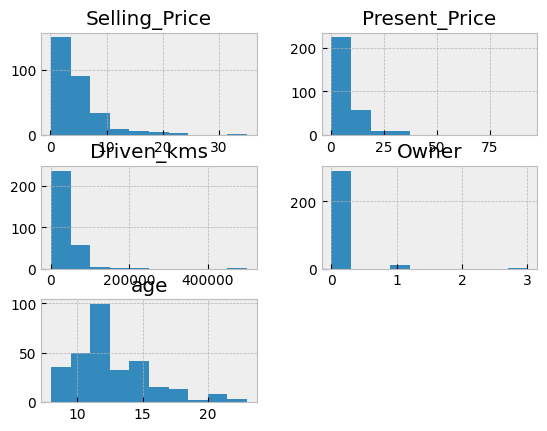

In [13]:
plt.figure(figsize=(10,13))
df.hist()

Text(0.5, 1.05, 'Impact of Car Age and Transmission on Selling Price')

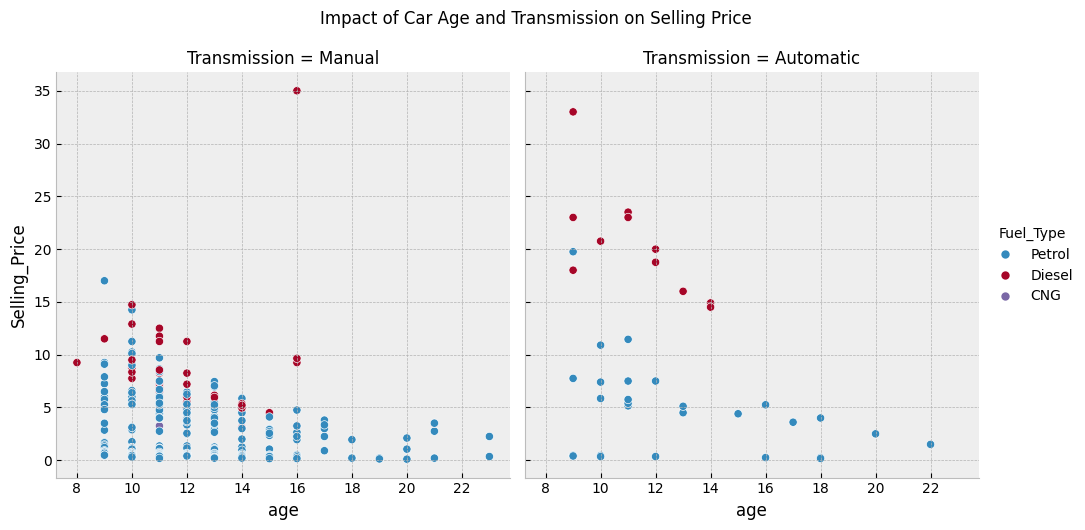

In [14]:
graph =sns.relplot(data=df, x='age', y='Selling_Price',hue='Fuel_Type', col='Transmission', kind='scatter')
graph.fig.suptitle("Impact of Car Age and Transmission on Selling Price", y=1.05)

Text(0.5, 1.0, 'Outliers in Present Price')

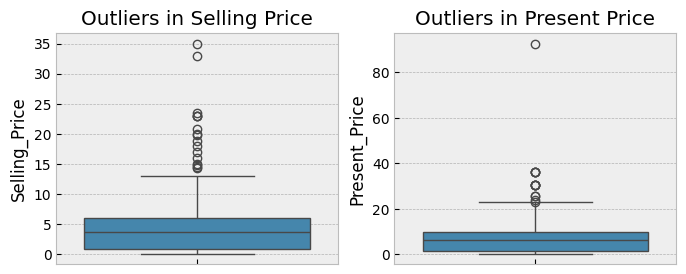

In [15]:
plt.figure(figsize =(8,3))

plt.subplot(1, 2, 1)
sns.boxplot(y=df['Selling_Price'])
plt.title('Outliers in Selling Price')

plt.subplot(1,2,2)
sns.boxplot(y=df['Present_Price'])
plt.title('Outliers in Present Price')

In [16]:
df =pd.get_dummies(df,['Fuel_Type','Selling_type','Transmission'],drop_first=True)
df =df.replace({True :1 , False :0})

C:\Users\XPRISTO\AppData\Local\Temp\ipykernel_22068\2455477333.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df =df.replace({True :1 , False :0})


<Axes: >

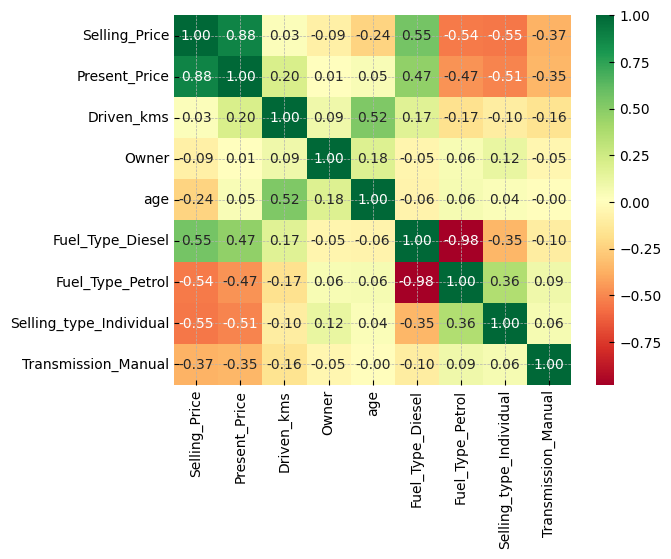

In [17]:
corr =df.corr()
sns.heatmap(corr,annot=True ,cmap='RdYlGn',fmt='.2f')

In [18]:
df.isnull().sum()
df.duplicated().sum()

np.int64(2)

## Handling Outliers

In [19]:
outlier_selling_price =df[df['Selling_Price']>10].index
df.drop(outlier_selling_price,axis=0,inplace=True)
outlier_Present_price =df[df['Present_Price'] >20].index
df.drop(outlier_Present_price,axis=0,inplace=True)

In [20]:
df['Driven_kms'] = np.log1p(df['Driven_kms'])

In [21]:
X = df.drop('Selling_Price', axis=1)
y = df['Selling_Price']

print(f"X shape: {X.shape}, y shape: {y.shape}") 

X shape: (268, 8), y shape: (268,)


## Data Splitting & Scaling

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# الـ Scaling
scaler = StandardScaler()
X_train_scale = scaler.fit_transform(X_train)
X_test_scale = scaler.transform(X_test)

In [23]:
model = LinearRegression()


model.fit(X_train_scale, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## 10. Conclusion
- The **Random Forest** model achieved a high accuracy of **94.84%**.
- **Present Price** and **Age** are the top factors influencing car value.
- The system is now ready to provide reliable price estimations for new car listings.

In [24]:
y_pred = model.predict(X_test_scale)

score = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"R2 Score (Accuracy): {score * 100:.2f}%")
print(f"Mean Absolute Error: {mae:.2f}")

R2 Score (Accuracy): 84.38%
Mean Absolute Error: 0.72


In [25]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

rf_model.fit(X_train_scale, y_train)

rf_pred = rf_model.predict(X_test_scale)
rf_accuracy = r2_score(y_test, rf_pred)

print(f"Random Forest Accuracy: {rf_accuracy * 100:.2f}%")

Random Forest Accuracy: 94.85%


## Insights: What Drives the Price?

In [ ]:
X.columns
Index(['Present_Price', 'Driven_kms', 'Owner', 'age', 'Fuel_Type_Diesel',
       'Fuel_Type_Petrol', 'Selling_type_Individual', 'Transmission_Manual'],
      dtype='object')

Index(['Present_Price', 'Driven_kms', 'Owner', 'age', 'Fuel_Type_Diesel',
       'Fuel_Type_Petrol', 'Selling_type_Individual', 'Transmission_Manual'],
      dtype='object')

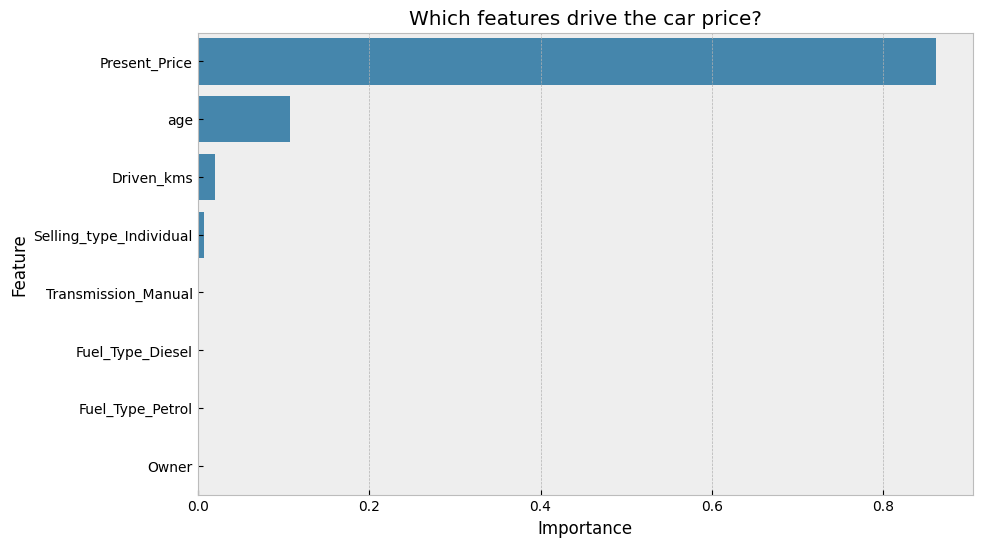

In [26]:
importances = rf_model.feature_importances_
feature_names = X.columns

feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title('Which features drive the car price?')
plt.show()


In [27]:
model = joblib.dump(rf_model ,'Car_model.pkl')
scaler = joblib.dump(scaler ,'scaler.pkl')

In [28]:
# def predict_car_price(new_data):
#     new_data['Driven_kms'] = np.log1p(new_data['Driven_kms'])
    
#     new_data_scaled = scaler.transform(new_data)
    
#     prediction = rf_model.predict(new_data_scaled)
#     return f"The faire Price  {prediction[0]:.2f}"

